# **環境設定、檔案讀取**

1. 上傳到 Google Drive

In [12]:
import os
import zipfile
import glob
import shutil
import numpy as np

# 1. 定義路徑
zip_path = '/content/drive/MyDrive/final.zip'
extract_dir = '/content/wce_data'

# 2. 嚴格檢查雲端硬碟檔案
if not os.path.exists(zip_path):
    print(f"錯誤：找不到雲端硬碟上的壓縮檔：{zip_path}")
else:
    print(f"成功定位雲端硬碟檔案：{zip_path}")

    # 3. 清空舊暫存
    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)
    os.makedirs(extract_dir)

    # 4. 執行解壓縮
    print("正在解壓縮，請稍候...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("解壓縮程序執行完畢！")

    # 5. 檢視解壓後的第一層目錄
    unzipped_contents = os.listdir(extract_dir)


    # 第一層叫做 'GastrointestinalBleeding'
    base_path = os.path.join(extract_dir, 'GastrointestinalBleeding')

    # 預防萬一，先印出 GastrointestinalBleeding 裡面有什麼
    if os.path.exists(base_path):
        inner_contents = os.listdir(base_path)
        print(f"{unzipped_contents[0]} 內的實際資料夾: {inner_contents}")
    else:
        # 如果結構有變，退回上一層搜尋
        base_path = extract_dir
        inner_contents = os.listdir(base_path)

    # 6. 使用不區分大小寫的智慧搜尋 (萬一資料夾叫 normal 或 Normal 都能找到)
    # 利用 glob 的遞迴 (**) 往所有子目錄深挖
    normal_paths = glob.glob(os.path.join(extract_dir, '**', '*[Nn]ormal*/*.*'), recursive=True)

    # 如果路徑不是 Normal 而是其他命名，我們嘗試用 Lesion 搜尋
    lesion_paths = glob.glob(os.path.join(extract_dir, '**', '*[Ll]esion*/*.*'), recursive=True)

    # 如果上面智慧搜尋沒抓到，退回傳統的強制路徑組合 (針對特定狀況)
    if len(normal_paths) == 0:
        normal_paths = glob.glob(os.path.join(base_path, 'Normal', '*.*'))
    if len(lesion_paths) == 0:
        lesion_paths = glob.glob(os.path.join(base_path, 'Lesion', '*.*'))

    # 7. 顯示最終結果
    print(f"\n【最終影像擷取結果】")
    print(f"找到 Normal 影像: {len(normal_paths)} 張")
    print(f"找到 Lesion 影像: {len(lesion_paths)} 張")

    # 8. 建立對應的標籤與陣列
    if len(normal_paths) == 113 and len(lesion_paths) == 113:
        all_paths = np.array(normal_paths + lesion_paths)
        all_labels = np.array([0] * len(normal_paths) + [1] * len(lesion_paths))
        print("\n讀取 226 張影像。資料路徑與標籤記憶體配置成功！")
    elif len(normal_paths) > 0 or len(lesion_paths) > 0:
        print(f"\n警告：有抓到圖片，但數量不是 113 張。請確認是否有多餘的隱藏檔 (例如 .DS_Store) 被讀入了。")
    else:
        print("\n錯誤：還是找不到圖片。請檢查剛才印出的「實際資料夾」名稱是否拼字有異。")

成功定位雲端硬碟檔案：/content/drive/MyDrive/final.zip
正在解壓縮，請稍候...
解壓縮程序執行完畢！
GastrointestinalBleeding 內的實際資料夾: ['Lesion', 'Normal']

【最終影像擷取結果】
找到 Normal 影像: 113 張
找到 Lesion 影像: 113 張

讀取 226 張影像。資料路徑與標籤記憶體配置成功！


2. 直接上傳檔案：慢

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import os
import glob
from sklearn.model_selection import KFold
import numpy as np
import zipfile
from google.colab import files

# 檢查是否有 GPU 可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的運算設備: {device}")

# 喚出上傳介面 (執行這行時會出現按鈕讓你選取檔案)
print("請點擊下方按鈕上傳 final.zip：")
uploaded = files.upload()

# 定義解壓縮的目的地
extract_dir = '/content/wce_data'

# 如果還沒建立資料夾就建立一個
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# 自動尋找上傳的 zip 檔並解壓縮
# uploaded 是一個字典，key 是檔名
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        zip_path = filename
        print(f"\n正在解壓縮 {zip_path} ...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("解壓縮完成！")

# 確認路徑與搜集影像
# 假設解壓縮後，內部結構為 final/Normal 和 final/Lesion
normal_dir = os.path.join(extract_dir, 'final', 'Normal')
lesion_dir = os.path.join(extract_dir, 'final', 'Lesion')

# 搜集所有圖片的絕對路徑
normal_paths = glob.glob(os.path.join(normal_dir, '*.*'))
lesion_paths = glob.glob(os.path.join(lesion_dir, '*.*'))

print(f"找到 Normal 影像: {len(normal_paths)} 張")
print(f"找到 Lesion 影像: {len(lesion_paths)} 張")

# 建立對應的標籤 (0 代表 Normal, 1 代表 Lesion)
all_paths = np.array(normal_paths + lesion_paths)
all_labels = np.array([0] * len(normal_paths) + [1] * len(lesion_paths))

目前使用的運算設備: cuda
請點擊下方按鈕上傳 final.zip：


KeyboardInterrupt: 

# **資料擴增**

針對 226 張極小資料集的 Transform 轉換矩陣。

In [13]:
# 訓練集專用的轉換矩陣：加入合理的幾何與光學隨機干擾
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # EfficientNet-B0 的標準輸入大小
    transforms.RandomHorizontalFlip(p=0.5), # 隨機水平翻轉
    transforms.RandomVerticalFlip(p=0.5),   # 隨機垂直翻轉
    transforms.RandomRotation(degrees=90),  # 腸道無絕對方向，可大膽旋轉
    # 限制色彩變換：只動亮度與對比度，嚴格禁止改變色相(hue=0)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0),
    transforms.ToTensor(),
    # ImageNet 標準化數值，確保預訓練權重正確激活
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 驗證/測試集專用的轉換矩陣：絕對不能有隨機干擾，只需 Resize 與標準化
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# **模型處理**

**重建 EfficientNet-B0 特徵萃取器**

我們載入預訓練模型，凍結底層的卷積特徵提取網路，並自行打造一個防過擬合的分類器（Classifier）。

In [14]:
def create_wce_model():
    # 1. 載入帶有 ImageNet 權重的 EfficientNet-B0
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # 2. 凍結（Freeze）所有特徵萃取層的權重
    for param in model.features.parameters():
        param.requires_grad = False

    # 3. 獲取原先分類器輸入的特徵維度 (EfficientNet-B0 是 1280)
    num_ftrs = model.classifier[1].in_features

    # 4. 重建分類器 (包含強烈的 Dropout 預防死背)
    # 我們設定輸出為 2 (Normal=0, Lesion=1)，後續使用 CrossEntropyLoss 處理
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5, inplace=True),
        nn.Linear(num_ftrs, 2)
    )

    return model.to(device)

# 實例化模型並檢視最後幾層的架構
wce_model = create_wce_model()
print(wce_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


Sequential(
  (0): Dropout(p=0.5, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


# **資料處理**

實作自定義的 Dataset 類別

In [15]:
class WCEDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # 告訴 DataLoader 總共有幾筆資料
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 根據索引讀取特定圖片
        img_path = self.file_paths[idx]

        # 確保讀取為 RGB 格式 (避免有些圖片是灰階或帶有 Alpha 通道)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        # 套用影像擴增與預處理
        if self.transform:
            image = self.transform(image)

        # 為了配合 CrossEntropyLoss，標籤必須轉換為 long 格式的張量
        return image, torch.tensor(label, dtype=torch.long)

**5-Fold**

建立 5-Fold 交叉驗證迴圈架構：檢測用程式碼

做5次的80/20分割。

把226張影像，盡量平均切成5個等份（每個等份大約45張圖）。我們稱它們為區塊A,B,C,D,E。

輪流考試（Fold 1到5）：
Fold 1： 拿A當考題（驗證集），用B,C,D,E當課本（訓練集）來教模型。考完紀錄分數。

Fold 2： 模型記憶全部洗掉重來。這次拿B當考題，用A,C,D,E來教模型。考完紀錄分數。

Fold 3： 拿C當考題，用A,B,D,E來教模型。

... 以此類推，直到 5 個回合結束。

模型根本不記得上一個Fold裡看過什麼圖片，每次執行都是全新的EfficientNet-B0。



In [16]:
# 設定 5-Fold，並設定 random_state 確保每次實驗的切分結果一致，方便 debug
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 定義 Batch Size (因為模型輕量且資料少，可以設 16 或 32)
batch_size = 16

# 這裡是 K-Fold 的主迴圈
for fold, (train_idx, val_idx) in enumerate(kf.split(all_paths)):
    print(f"\n========== 開始執行 Fold {fold + 1}/5 ==========")

    # 1. 根據索引切分當前 Fold 的訓練集與驗證集路徑/標籤
    train_paths, val_paths = all_paths[train_idx], all_paths[val_idx]
    train_labels, val_labels = all_labels[train_idx], all_labels[val_idx]

    # 2. 實例化 Dataset，並嚴格指派對應的 Transform
    # 訓練集：使用帶有隨機幾何與光影干擾的 train_transforms
    train_dataset = WCEDataset(train_paths, train_labels, transform=train_transforms)
    # 驗證集：只能使用標準化的 val_transforms，嚴禁任何干擾
    val_dataset = WCEDataset(val_paths, val_labels, transform=val_transforms)

    # 3. 建立 DataLoader，負責將資料打包成 Batch 餵給模型
    # 訓練集需要打亂順序 (shuffle=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    # 驗證集不需要打亂 (shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"Fold {fold + 1} - 訓練集數量: {len(train_dataset)}, 驗證集數量: {len(val_dataset)}")

    # ==========================================
    # 這裡將會放入「模型初始化」、「優化器設定」與「訓練與驗證的內部迴圈」
    # ==========================================

    # 為了方便分段理解，我們暫時在這裡用 break 中斷。
    # 等確認結構沒問題後，再把實際的訓練邏輯填進來。
    break


========== 開始執行 Fold 1/5 ==========
Fold 1 - 訓練集數量: 180, 驗證集數量: 46


# **模型訓練與驗證**

**訓練與評估**

In [ ]:
import copy
from sklearn.metrics import accuracy_score, recall_score, classification_report # <--- 新增 classification_report
import torch.nn as nn
import torch.optim as optim

# 設定總訓練回合數與早停容忍度
EPOCHS = 30
PATIENCE = 5  # 如果驗證集 Loss 連續 5 個 Epoch 沒下降就提早停止

# 紀錄五個 Fold 的最終成績
fold_results = []


# 建立空陣列，用來收集 5 個 Fold 最佳 Epoch 的所有預測結果 (總共會收集滿 226 張)
oof_true = []
oof_preds = []

# 這裡接續你的 K-Fold 主迴圈
for fold, (train_idx, val_idx) in enumerate(kf.split(all_paths)):
    print(f"\n{'='*20} 開始執行 Fold {fold + 1}/5 {'='*20}")

    train_paths, val_paths = all_paths[train_idx], all_paths[val_idx]
    train_labels, val_labels = all_labels[train_idx], all_labels[val_idx]

    train_dataset = WCEDataset(train_paths, train_labels, transform=train_transforms)
    val_dataset = WCEDataset(val_paths, val_labels, transform=val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    model = create_wce_model()
    # 給予 Lesion (類別 1) 兩倍的權重，Normal (類別 0) 維持一倍
    class_weights = torch.tensor([1.0, 2.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2)

    # 早停機制的追蹤變數
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    # ==========================================
    # [新增] 用來暫存「這個 Fold 表現最好」那一次的預測結果
    # ==========================================
    best_fold_preds = []
    best_fold_true = []

    for epoch in range(EPOCHS):
        # [訓練階段]
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_dataset)

        # [驗證階段]
        model.eval()   # 關閉 Dropout，鎖定模型狀態
        val_loss = 0.0
        all_preds = []
        all_true = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # 視角 1：原圖預測
                outputs_orig = model(inputs)
                # 使用 Softmax 將輸出轉換為 0~1 的機率分佈
                prob_orig = torch.softmax(outputs_orig, dim=1)

                # 視角 2：水平翻轉預測 (沿著維度 3 翻轉)
                inputs_hflip = torch.flip(inputs, dims=[3])
                outputs_hflip = model(inputs_hflip)
                prob_hflip = torch.softmax(outputs_hflip, dim=1)

                # 視角 3：垂直翻轉預測 (沿著維度 2 翻轉)
                inputs_vflip = torch.flip(inputs, dims=[2])
                outputs_vflip = model(inputs_vflip)
                prob_vflip = torch.softmax(outputs_vflip, dim=1)

                # 核心魔法：將三個視角的機率相加後平均
                prob_final = (prob_orig + prob_hflip + prob_vflip) / 3.0

                # 計算 Loss (為了保持 Early Stopping 機制正常運作，我們還是用原圖的 Loss 來追蹤)
                loss = criterion(outputs_orig, labels)
                val_loss += loss.item() * inputs.size(0)

                # 根據「融合後的機率 (prob_final)」來做最終決定，取出機率最高的類別
                _, preds = torch.max(prob_final, 1)

                all_preds.extend(preds.cpu().numpy())
                all_true.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(val_dataset)
        epoch_acc = accuracy_score(all_true, all_preds)
        epoch_recall = recall_score(all_true, all_preds, pos_label=1, zero_division=0)

        print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_acc:.4f} | "
              f"Val Recall: {epoch_recall:.4f}")

        # 核心 3：Early Stopping 邏輯與預測結果紀錄
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())

            # [新增] 只要這個 Epoch 的 Loss 創新低，就把預測結果備份下來
            # 使用 .copy() 避免被下一個 Epoch 的數據覆蓋
            best_fold_preds = all_preds.copy()
            best_fold_true = all_true.copy()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"--- 觸發 Early Stopping！在 Epoch {epoch+1} 停止訓練 ---")
                break

    model.load_state_dict(best_model_wts)
    print(f"-> Fold {fold + 1} 最佳 Val Loss: {best_val_loss:.4f}")
    fold_results.append(best_val_loss)

    # [新增] 將這個 Fold 最佳的預測結果，匯入總結算清單中
    oof_true.extend(best_fold_true)
    oof_preds.extend(best_fold_preds)

print("\n" + "="*50)
print(f"5-Fold Cross Validation 結束！")
print(f"平均驗證誤差 (Average Val Loss): {sum(fold_results)/5:.4f}")


==================== 開始執行 Fold 1/5 ====================
Epoch  1/30 | Train Loss: 0.6591 | Val Loss: 0.6609 | Val Acc: 0.6304 | Val Recall: 1.0000
Epoch  2/30 | Train Loss: 0.5956 | Val Loss: 0.6137 | Val Acc: 0.6087 | Val Recall: 0.8966
Epoch  3/30 | Train Loss: 0.5881 | Val Loss: 0.5967 | Val Acc: 0.6522 | Val Recall: 0.9310
Epoch  4/30 | Train Loss: 0.5668 | Val Loss: 0.5954 | Val Acc: 0.6739 | Val Recall: 0.7931
Epoch  5/30 | Train Loss: 0.5336 | Val Loss: 0.5684 | Val Acc: 0.6957 | Val Recall: 0.8966
Epoch  6/30 | Train Loss: 0.4602 | Val Loss: 0.5473 | Val Acc: 0.6522 | Val Recall: 0.8966
Epoch  7/30 | Train Loss: 0.4931 | Val Loss: 0.5362 | Val Acc: 0.7174 | Val Recall: 0.8966
Epoch  8/30 | Train Loss: 0.4443 | Val Loss: 0.5210 | Val Acc: 0.7826 | Val Recall: 0.8621
Epoch  9/30 | Train Loss: 0.4951 | Val Loss: 0.5042 | Val Acc: 0.8043 | Val Recall: 0.8621
Epoch 10/30 | Train Loss: 0.4801 | Val Loss: 0.5007 | Val Acc: 0.7609 | Val Recall: 0.8276
Epoch 11/30 | Train Loss: 0.4824 

# **結果展示**

分類報告

In [25]:
print("\n" + "="*15 + " 最終測試集 (OOF Test Set) 評估報告 " + "="*15)
# 對應標籤 0: Normal, 1: Lesion
target_names = ['Normal', 'Lesion']
# digits=2 代表顯示到小數點後兩位，確保排版要求的格式一致
final_report = classification_report(oof_true, oof_preds, target_names=target_names, digits=2)
print(final_report)


=============== 最終測試集 (OOF Test Set) 評估報告 ===============
              precision    recall  f1-score   support

      Normal       0.81      0.76      0.79       113
      Lesion       0.78      0.82      0.80       113

    accuracy                           0.79       226
   macro avg       0.79      0.79      0.79       226
weighted avg       0.79      0.79      0.79       226



混淆矩陣

/tmp/ipykernel_1960/1198530729.py:32: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1960/1198530729.py:32: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1960/1198530729.py:32: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1960/1198530729.py:32: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1960/1198530729.py:32: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1960/1198530729.py:32: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1960/1198530729.py:32: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}

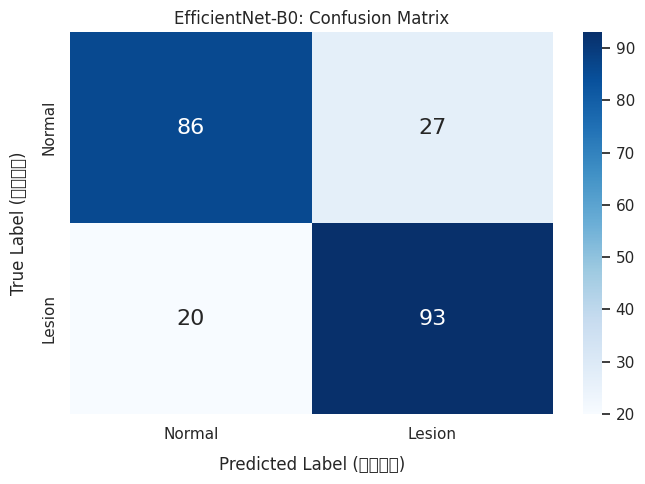

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 繪製 5-Fold 總結混淆矩陣 (OOF Confusion Matrix)
# ==========================================

# 1. 產生混淆矩陣陣列
# 傳入我們剛剛收集好的真實標籤 (oof_true) 與預測標籤 (oof_preds)
cm = confusion_matrix(oof_true, oof_preds)

# 2. 設定畫布大小與風格
plt.figure(figsize=(7, 5))
sns.set_theme(style="white") # 清除背景格線，讓熱力圖更乾淨

# 3. 繪製熱力圖 (Heatmap)
# annot=True: 顯示格子內的數值
# fmt='d': 強制以整數顯示 (避免變成科學記號)
# cmap='Blues': 使用漸層藍色系 (數值越大顏色越深)
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=['Normal', 'Lesion'],
                 yticklabels=['Normal', 'Lesion'],
                 annot_kws={"size": 16}) # 將數字放大

# 4. 設定圖表標題與座標軸標籤
plt.title('EfficientNet-B0: Confusion Matrix')
plt.xlabel('Predicted Label (模型預測)', fontsize=12, labelpad=10)
plt.ylabel('True Label (實際病理)', fontsize=12, labelpad=10)

# 5. 確保標籤顯示不被裁切並顯示圖表
plt.tight_layout()
plt.show()

**熱力圖**

安裝 Grad-CAM 套件

In [27]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6dd4d5466c8161e3402b3d27fdeeba14ce5c828c068ba7e939595cec9c464819
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


隨機抽出5張Lesion病灶的圖片，顯示關注區域

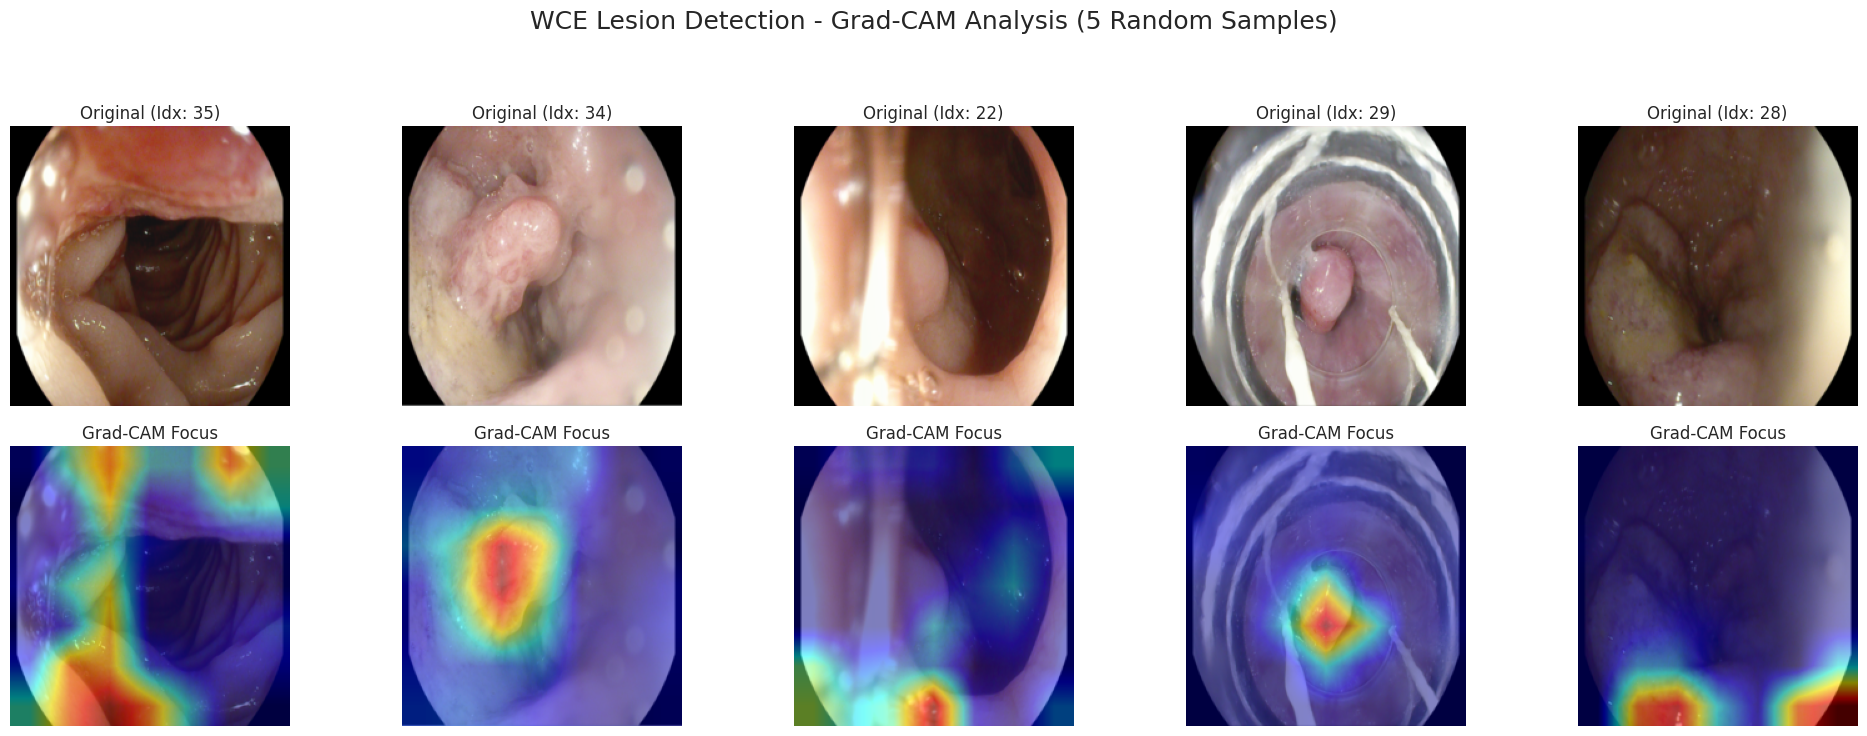

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ==========================================
# 確保梯度開啟 (避免 NoneType 錯誤)
# ==========================================
for param in model.parameters():
    param.requires_grad = True
model.eval()

# ==========================================
# 初始化 Grad-CAM 引擎
# ==========================================
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(1)]

# ==========================================
# 隨機挑選 5 張 Lesion 圖片並視覺化
# ==========================================
# 找出驗證集中實際為 Lesion 的索引
lesion_indices = [i for i in range(len(val_dataset)) if val_dataset[i][1].item() == 1]

# 決定要抽取的數量 (預設 5 張，如果該 Fold 驗證集剛好少於 5 張則全拿)
num_samples = min(5, len(lesion_indices))

if num_samples > 0:
    # 不重複地隨機抽取 5 個索引
    sampled_indices = random.sample(lesion_indices, num_samples)

    # 建立畫布：2 列 (Original, Grad-CAM) x 5 行，並設定足夠寬的尺寸
    fig, axes = plt.subplots(2, num_samples, figsize=(4 * num_samples, 7))

    # 反正規化用的常數
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i, idx in enumerate(sampled_indices):
        # 1. 讀取與預處理
        img_tensor, label = val_dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        # 2. 產生熱力圖
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        # 3. 還原原圖
        img_np = input_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        # 4. 疊加影像
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        # 5. 畫在上半部 (第一列)：原始圖片
        # 注意：如果 num_samples 只有 1，axes 會是一維陣列，所以這裡加了防呆處理
        ax_orig = axes[0, i] if num_samples > 1 else axes[0]
        ax_orig.imshow(img_np)
        ax_orig.set_title(f"Original (Idx: {idx})", fontsize=12)
        ax_orig.axis('off')

        # 6. 畫在下半部 (第二列)：熱力圖
        ax_cam = axes[1, i] if num_samples > 1 else axes[1]
        ax_cam.imshow(visualization)
        ax_cam.set_title("Grad-CAM Focus", fontsize=12)
        ax_cam.axis('off')

    # 整體排版與顯示
    plt.suptitle(f"WCE Lesion Detection - Grad-CAM Analysis ({num_samples} Random Samples)", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("錯誤：在這個 Fold 的驗證集中找不到 Lesion 圖片。")

# **底層邏輯**

EfficientNet-B0 + 凍結底層 + 兩倍 Lesion 權重 + TTA 測試擴增 + 226張圖的資料前處理。

給予Lesion(類別1)兩倍的權重，Normal(類別0)維持一倍。

TTA：將預測的照片變出多種不同的版本去預測，將機率平均後診斷。
